---
---

<h1><center><ins>Numerical methods: exam 2</ins></center></h1>
<h2><center>28th of of January, 9:45-11:15<br><br>

---
---

## Exercise 1 (9 points) - DSMC:

Using the **DSMC method**, calculate the surface area of an ellipse with the semi-major axis $a$ and the semi-minor axis $b$.


**Approach:**
In order to do this, create a 2-dimensional domain (defined by the coordinates $a, b$) and launch a number P of particles at random locations within. Check which particles lie inside the ellipse using the following condition:

$$\frac{x^2}{a^2} + \frac{y^2}{b^2} \le 1$$


**a)** Estimate the surface area of the ellipse as the ratio between the surface area of the whole domain and the ellise by checking the number of particles generated within and outside the ellipse. Stop the calculation once you have reached the precision level of 1 per cent compared to the analytical estimate. 

**b)** Print the surface area. Compare to the analytically computed surface area for the ellipse and show that you have reached the desired precision level. Print the number of particles you've needed to reach this precision.

**c)** Make a scatter plot for your domain, highlighting the particles that are inside the ellipse.


Area estimate: 39.00 % of the whole domain


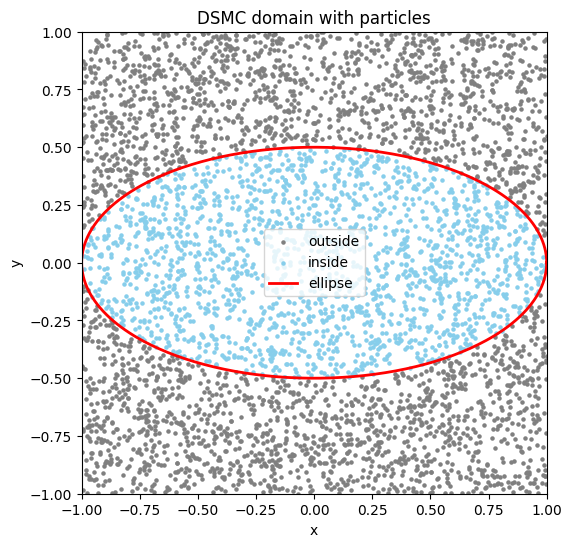

In [50]:
import numpy as np
import matplotlib.pyplot as plt

def ellipse(x, y, a=1, b=2):
    return x**2 / a**2 + y**2 / b**2 - 1


xmin, xmax = -1, 1
ymin, ymax = xmin, xmax

a,b = 1,0.5

Np = 5000

x = np.random.uniform(xmin, xmax, Np)
y = np.random.uniform(ymin, ymax, Np)


inside = x**2 / a**2 + y**2 / b**2 <= 1
n = np.sum(inside)

fraction_under = n / Np

# Area estimate (domain area is 1.0)
area_estimate = fraction_under * 1.0


print(f"Area estimate: {(area_estimate*100):.2f} % of the whole domain")

plt.figure(figsize=(6, 6))


plt.scatter(x[~inside], y[~inside], s=5, color="gray", label="outside")
plt.scatter(x[inside], y[inside], s=5, color="skyblue", label="inside")

# Calculate ellipse boundary
theta = np.linspace(0, 2*np.pi, 400)
x_e = a * np.cos(theta)
y_e = b * np.sin(theta)

plt.plot(x_e, y_e, color="red", linewidth=2, label="ellipse")


plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.legend(loc="center")
plt.xlabel("x")
plt.ylabel("y")
plt.title("DSMC domain with particles")

plt.show()

Area estimate: 1261.71 % of the whole domain
400 points were used
estimated area = 12.617142857142857, analytical area = 12.566370614359172
|estimate - analytical| / analytical: 0.004040326705442638


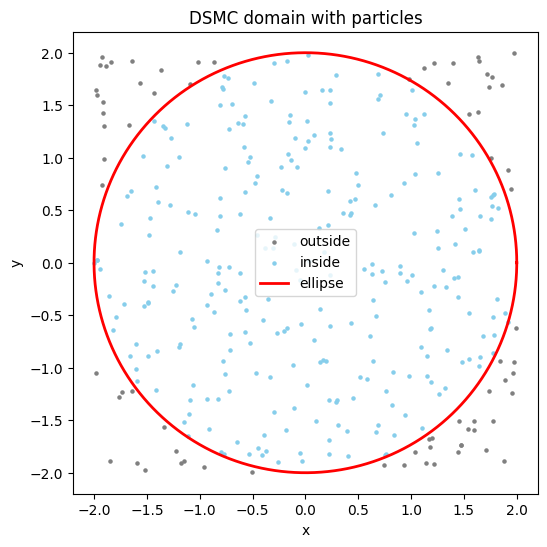

In [ ]:
# code where i tried to implement precision but it is not correct

import numpy as np
import matplotlib.pyplot as plt

def ellipse(x, y, a=1, b=2):
    return x**2 / a**2 + y**2 / b**2 - 1


a,b = 2,2
analytical_area = np.pi * a * b

def estimate_ellipse(P):
    x = np.random.uniform(-a, a, P)
    y = np.random.uniform(-b, b, P)

    inside = x**2 / a**2 + y**2 / b**2 <= 1
    n = np.sum(inside)

    fraction_under = n / P

    domain_area = (2 * a) * (2 * b)
    estimated_area = domain_area * fraction_under

    return estimated_area, x, y, inside


target_precision = 0.01
P = 100
estimated_area = 0
error = float('inf')

P_values = []
errors = []

while error > target_precision:
    estimated_area, x, y, inside = estimate_ellipse(P)
    error = np.abs(estimated_area - analytical_area) / analytical_area
    
    P_values.append(P)
    errors.append(error)
    
    P += 50



print(f"{P} points were used")
print(f"estimated area = {estimated_area}, analytical area = {analytical_area}")
print(f"|estimate - analytical| / analytical: {np.abs(estimated_area - analytical_area) / analytical_area}")

plt.figure(figsize=(6, 6))


plt.scatter(x[~inside], y[~inside], s=5, color="gray", label="outside")
plt.scatter(x[inside], y[inside], s=5, color="skyblue", label="inside")

# Calculate ellipse boundary
theta = np.linspace(0, 2*np.pi, 400)
x_e = a * np.cos(theta)
y_e = b * np.sin(theta)

plt.plot(x_e, y_e, color="red", linewidth=2, label="ellipse")


# plt.xlim(xmin, xmax)
# plt.ylim(ymin, ymax)
plt.legend(loc="center")
plt.xlabel("x")
plt.ylabel("y")
plt.title("DSMC domain with particles")
plt.show()

## Exercise 2 (9 points) - fitting models to a dataset:

On moodle together with the exam files, you can find the file titled ```Trajectory.txt```. The dataset presents a mock measured trajectory of a particle. Your aim is to determine using the fitting methods if the data corresponds to the particle moving with a constant velocity or if there was an additional acceleration present.

**(A)** Load the dataset into your programme. Skip the caption.

**(B)** Using the embedded functions linregress and curve_fit, fit a straight line and a parabola to the dataset. Which fit corresponds to the motion with a constant velocity, and which fit describes accelerated motion?

**(C)** Output the $\chi^2$ for the first and second fit. Which model fits the dataset better?

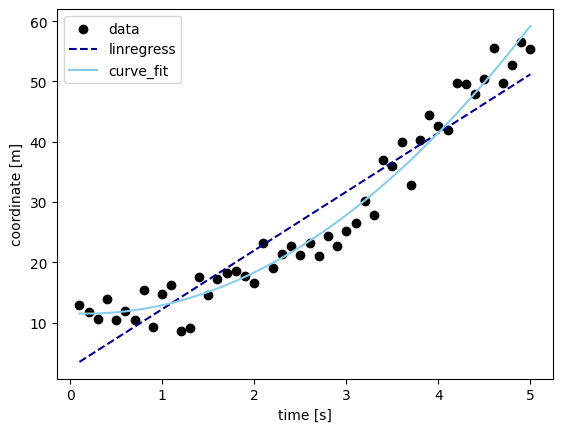

linear fit represents motion with constant velocity and parabolic fit represents accelerated motion
Chi² (linregress) = 1095.10, Chi²/ndof = 22.81
Chi² (curve_fit) = 367.77, Chi²/ndof = 7.82
curve_fit fits the dataset better.


In [45]:
from numpy.polynomial.polynomial import Polynomial
from scipy.stats import linregress
from scipy.optimize import curve_fit

t, x = np.loadtxt("Trajectory.txt", unpack=True, skiprows=2)

lin = linregress(t, x)
slope_lr, intercept_lr = lin.slope, lin.intercept
slope_err_lr, intercept_err_lr = lin.stderr, lin.intercept_stderr
r_value_lr = lin.rvalue


# curve_fit
def parabola(t, a, b, c):
    return a*t**2 + b*t + c

popt, pcov = curve_fit(parabola, t, x)
a_cf, b_cf, c_cf = popt
a_err_cf, b_err_cf, c_err_cf = np.sqrt(np.diag(pcov))
r_ab_cf = pcov[0,1] / (a_err_cf * b_err_cf * c_err_cf)

plt.scatter(t, x, label="data", color="black")
tfit = np.linspace(np.min(t), np.max(t), 100)
plt.plot(tfit, slope_lr*tfit + intercept_lr, '--', label='linregress', color="darkblue")
plt.plot(tfit, a_cf*tfit**2 + b_cf*tfit + c_cf, '-', label='curve_fit', color="skyblue")
plt.xlabel("time [s]")
plt.ylabel("coordinate [m]")
plt.legend()
plt.show()

print(f"linear fit represents motion with constant velocity and parabolic fit represents accelerated motion")

# C)
y_lin = slope_lr * t + intercept_lr
chi2_lin = np.sum((x - y_lin) ** 2)
ndof_lin = len(x) - 2  # 2 parameters: slope and intercept

print(f"Chi² (linregress) = {chi2_lin:.2f}, Chi²/ndof = {chi2_lin/ndof_lin:.2f}")

y_parab = parabola(t, a_cf, b_cf, c_cf)
chi2_parab = np.sum((x - y_parab) ** 2)
ndof_parab = len(x) - 3  # 3 parameters: a, b, c

print(f"Chi² (curve_fit) = {chi2_parab:.2f}, Chi²/ndof = {chi2_parab/ndof_parab:.2f}")

print("curve_fit fits the dataset better.")